In [1]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.odr import ODR, Model, RealData
%run ./TbIG_Experiment_Functions.ipynb

In [2]:
datas=[(pd.read_csv('SQUID_csv/TbIG_powder_temp_sweep_9Dec2024.dat.csv', header=None))]

#dvarnish = pd.read_csv('SQUID_csv/GE_Varnish_high_field.dat.csv', header=None)


In [3]:
# stats of small tbig sample:
voltbig = 3.075*1.607**2*np.pi
#masstbig = 0.0915
masstbig=0.0880
denstbig = 7.32*10**(-3) #g/mm^3, density is actually lower for our applications, like half
masstbigcalc = voltbig*denstbig

# stats of contaminated sample powder used:
masspowder = 0.0462

# stats of small dyig sample used:
massdyig = 0.023
voldyig = (3.218/2)**2*np.pi*0.979
densdyig = 6.61*10**(-3)
massdyigcalc = voldyig*densdyig

#masscontam = 7.97
#volcontam = 7.4*(19/2)**2*np.pi

# stats of 2024 NSR sample:
volNSR = 10*(19/2)**2*np.pi
massNSR = 12

molarmasstbig=948.04 #g/mol
molarmassdyig=958.75


#uB=1.07*10**20

# bohr magneton in erg/G
uB=9.274*10**(-21)

# Avogadro's constant
NA=6.022*10**23

# Conversions from emu (erg/G) to uB/molecule
convtbig=1/uB/masstbig*molarmasstbig/NA
#chi=0.05 #susceptibility
#convNSR = (chi*volNSR*molarmasstbig)/(massNSR*uB*NA)
convdyig=1/uB/massdyig*molarmassdyig/NA
convpowder = 1/uB/masspowder*molarmasstbig/NA
convNSR = 1/uB/massNSR*molarmasstbig/NA

conv = convpowder

In [4]:
temps=[]
mags=[]
temperrors=[]
magerrors=[]
start=41
end=54
for data in datas:
    mintemp = np.float64(data[35][start:end])
    maxtemp = np.float64(data[36][start:end])
    temp = (mintemp+maxtemp)/2
    mag = np.float64(data[4][start:end])
    magub = mag*conv

    magerror = np.float64(data[5][start:end])
    magerrorub = magerror*conv
    temperror = (-mintemp+maxtemp)/2
    temperror=[sorted(set(temperror))[1] if temperror[i]==0 else temperror[i] for i in np.arange(len(temperror))]

    temps.append(temp)
    if mag[0]<0:
        mags.append(magub)
    else:
        mags.append(magub)
    temperrors.append(temperror)
    magerrors.append(magerrorub)

In [12]:
betas=[]
plots=[]
comps=[]
deltas=[]

for i in np.arange(1):

    #get fit
    x,y,sigma_x,sigma_y = temps[i], mags[i], temperrors[i], magerrors[i]
    results=analysis(x, y, sigma_x, sigma_y)
    comps.append(results[2])
    deltas.append(results[3])
    beta=results[0]
    betas.append(beta)

moment at 10mk above =  5.447019593773916e-05 ub/molecule, 0.003850537565372359 emu for NSR sample
moment at 10mk below =  -6.148524045279657e-05 ub/molecule, -0.0043464361382150735 emu for NSR sample
Estimated T_comp for 300K: 248.49 +/- 0.22


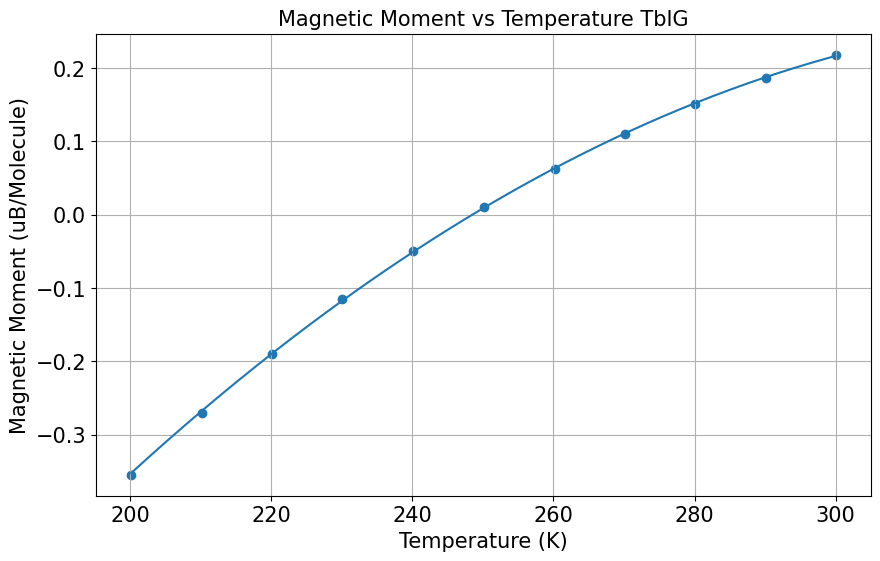

In [13]:
# Define plot space
fig, ax = plt.subplots(figsize=(10, 6))

SMALL_SIZE = 8
MEDIUM_SIZE = 12
BIGGER_SIZE = 15
huge=25

labels=["300K", "275K", "225K", "200K"]
#labels=[300, 275, 256, 225, 200]

ax.scatter(x, y)
ax.errorbar(x, y, xerr=sigma_x, yerr=sigma_y, fmt='none')
newx=np.arange(min(x), max(x), .1)
newy=beta[0]*newx**2+beta[1]*newx+beta[2]
plot,=ax.plot(newx,newy,label=labels[i])

#calculate moments at 10mk above and below tc
above = beta[0]*(comps[0]+0.01)**2+beta[1]*(comps[0]+0.01)+beta[2]
below = beta[0]*(comps[0]-0.01)**2+beta[1]*(comps[0]-0.01)+beta[2]
print(f"moment at 10mk above =  {above} ub/molecule, {above/convNSR} emu for NSR sample")
print(f"moment at 10mk below =  {below} ub/molecule, {below/convNSR} emu for NSR sample")

extra=np.float64([235,275])
#print(beta[0]*extra**2+beta[1]*extra+beta[2])

plots.append(plot)
#ax_inset.scatter(x, y)
#ax_inset.errorbar(x, y, xerr=sigma_x, yerr=sigma_y, fmt='none')
print(f"Estimated T_comp for {labels[i]}: {np.round(results[2],2)} +/- {np.round(results[3],2)}")

# Total uncertainty is (max-min)/2 divided by sqrt of sample number
#print(f"Total estimated T_comp: {np.round(np.mean(comps),2)} +/- {np.round(np.std(comps),2)}")

plt.rc('figure', titlesize=huge)  # fontsize of the figure title

# Set plot title and axes labels
ax.set(title = "Magnetic Moment vs Temperature TbIG",
       xlabel = "Temperature (K)",
       ylabel = "Magnetic Moment (uB/Molecule)")


plt.rc('font', size=huge)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=huge)  # fontsize of the figure title


# Plot the same data in the inset, but zoomed in
# Zoom in between x=2 and x=3
#ax_inset.set_xlim(x1, x2)
#ax_inset.set_ylim(y1, y2)
#ax_inset.set_xticks([])
#ax_inset.set_yticks([])
#ax_inset.set_title('10k Zoom')


#ax.legend(loc='center left')

ax.grid()

#plt.savefig('TbIG_Tcomp_4.png',dpi=200)

plt.show(plots)



In [15]:
(chi*volcontam*molarmasstbig)/(masscontam*uB*NA)

2.2343916762238885

In [9]:
.00005/convNSR

0.003534536179908021